Logistic Regression: A supervised ML algorithm used for classification problems that predicts probability (0 to 1) using a sigmoid function.
Use case: spam detection , disease prediction , fraud detection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score, classification_report
from sklearn.metrics import r2_score
from IPython.display import display
from sklearn.metrics import roc_curve , auc

In [2]:
# Importing Dataset
from sklearn.datasets import load_iris
data=load_iris()
# Information of Dataset
print(data.DESCR)
display(data)
display(data.feature_names)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [3]:
# Converting into DataFrame
df=pd.DataFrame(data.data,columns=data.feature_names)
df['Target']=data.target
display(df)
display(df.sample())
display(df.Target.unique())

# In this Implementation we will discuss about binary classification so i am removing the target value '2'
df=df[df['Target']!=2]
display(df.info())
display(df['Target'].value_counts())

# Splitting into X,Y
x=df.iloc[:,:-1]
y=df.iloc[:,-1]
display(x.head(1))
display(y.head(1))

# train test split 
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)
classifier=LogisticRegression()
classifier.fit(x_train,y_train)
y_pred=classifier.predict(x_test)
confusion_matrix_of_classifier=confusion_matrix(y_test,y_pred)
print(confusion_matrix(y_test,y_pred))
class_report=classification_report(y_test,y_pred)
print(classification_report(y_test,y_pred))
classifier.predict_proba(x_test)
# Probability for class 1 
y_pred_proba=classifier.predict_proba(x_test)[:,1]
display(y_pred_proba)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Target
111,6.4,2.7,5.3,1.9,2


array([0, 1, 2])

<class 'pandas.core.frame.DataFrame'>
Index: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  100 non-null    float64
 1   sepal width (cm)   100 non-null    float64
 2   petal length (cm)  100 non-null    float64
 3   petal width (cm)   100 non-null    float64
 4   Target             100 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 4.7 KB


None

Target
0    50
1    50
Name: count, dtype: int64

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2


0    0
Name: Target, dtype: int64

[[14  0]
 [ 0 11]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        11

    accuracy                           1.00        25
   macro avg       1.00      1.00      1.00        25
weighted avg       1.00      1.00      1.00        25



array([0.99867881, 0.9831867 , 0.9966476 , 0.03190162, 0.05903284,
       0.02965222, 0.00690603, 0.96660098, 0.02646032, 0.02210315,
       0.04620888, 0.04096295, 0.99527368, 0.01480939, 0.9900051 ,
       0.01948569, 0.9976837 , 0.99859233, 0.02667999, 0.04032925,
       0.99205519, 0.97688614, 0.0418408 , 0.01679891, 0.97191089])

array([0., 0., 0., 1.])

array([0.        , 0.09090909, 1.        , 1.        ])

array([       inf, 0.99867881, 0.96660098, 0.00690603])

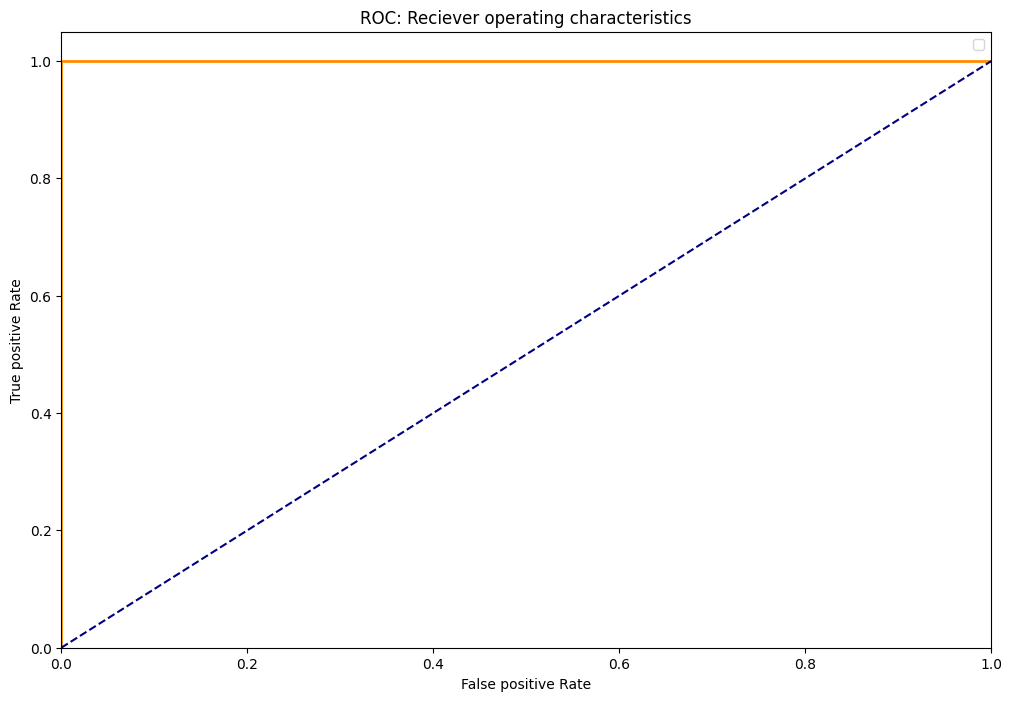

array([1., 1., 1., 1., 1.])

In [6]:
# roc: reciever operating characteristics curve
# input: y_test,y_pred_proba , and returns fpr,tpr,with different cutoff of probabilities
fpr,tpr,threshold=roc_curve(y_test,y_pred_proba)
display(fpr)
display(tpr)
display(threshold)
roc_auc=auc(fpr,tpr)

# Plotting the auc curve
plt.figure(figsize=(12,8))
plt.plot(fpr,tpr,color='darkorange',linewidth=2)
plt.plot([0,1],[0,1],color='navy',linestyle='--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('False positive Rate')
plt.ylabel('True positive Rate')
plt.title('ROC: Reciever operating characteristics')
plt.legend()
plt.show()
from sklearn.model_selection import cross_val_score
score=cross_val_score(classifier,x_train,y_train,scoring='accuracy')
display(score)